# Exercise 2

In [2]:
# this allows you to use "cd" in cells to change directories instead of requiring "%cd"
%automagic on
# override IPython's default %%bash to not buffer all output
from IPython.core.magic import register_cell_magic
@register_cell_magic
def bash(line, cell): get_ipython().system(cell)
# this (non-default package) keeps the end of shell output in view
try: import scrolldown
except ModuleNotFoundError: pass


Automagic is ON, % prefix IS NOT needed for line magics.


There are two possible reactions, which can occur:

1. $^{65}Ni + \gamma \rightarrow$ $^{64}Ni + n$
2. $^{64}Ni + n \rightarrow$ $^{65}Ni + \gamma$

# Run WinNet

In [4]:
%%bash
/home/teaching/WinNet/bin/winnet test.par >OUT 2>ERR

In [3]:

# Import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import *

In [5]:
t, n, ni64, ni65 = np.loadtxt("tracked_nuclei(1).dat",unpack=True)

Text(0.5, 0, 'time')

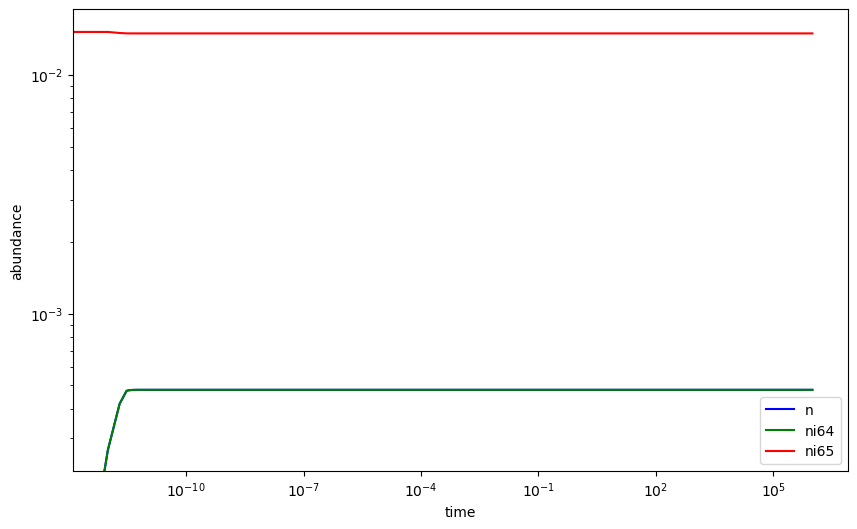

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(t, n, label="n", color="blue")
ax.loglog(t, ni64, label="ni64", color="green")
ax.loglog(t, ni65, label="ni65", color="red")

ax.legend()
ax.set_ylabel("abundance")
ax.set_xlabel("time")

We can observe two lines, a red one and one which seems like that the green and blue line overlap. This characterizes the behavior of these reactions pretty good, because the abundance of Ni65 (red) is starting constant as a result of the initial condition. After a brief time, we observe a dip in the Ni65 abundance with a sudden rise of neutrons and Ni64 (green and blue). This marks the start of the decay reaction Ni65 $\rightarrow$ Ni64 $+$ n. After that, we can see all three abundances constant. 

In [12]:
ni64

array([0.        , 0.0002681 , 0.00041885, 0.00047447, 0.00047577,
       0.00047655, 0.00047707, 0.00047737, 0.00047764, 0.00047788,
       0.00047845, 0.00047883, 0.00047905, 0.00047919, 0.00047928,
       0.00047936, 0.00047941, 0.00047943, 0.00047945, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047946,
       0.00047946, 0.00047946, 0.00047946, 0.00047946, 0.00047

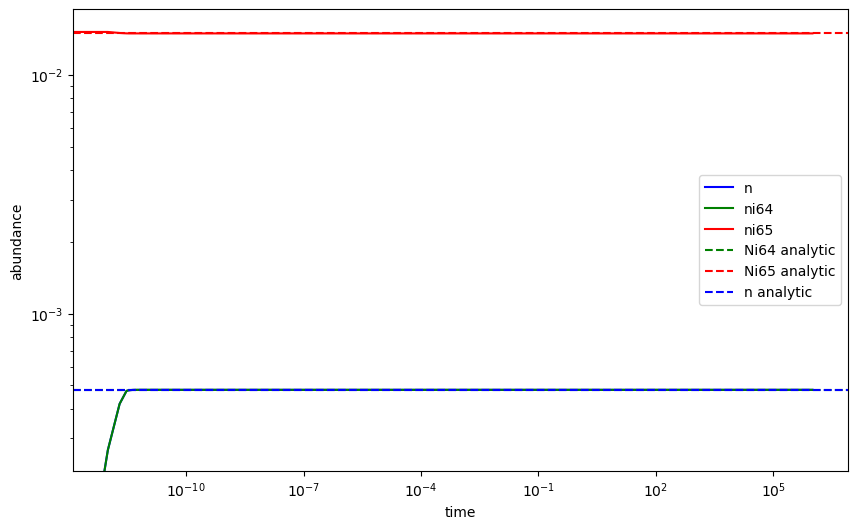

In [18]:
Lambda = 2.5778301257e10
NAsigmav = 1.670521e6
rho = 1e9
R = rho * NAsigmav

fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(t, n, label="n", color="blue")
ax.loglog(t, ni64, label="ni64", color="green")
ax.loglog(t, ni65, label="ni65", color="red")

ax.legend()
ax.set_ylabel("abundance")
ax.set_xlabel("time")

Y64 = 0.00047946#normalized to the converged result of WINNET
YN = Y64
Y65 = R/Lambda * Y64 * YN

ax.axhline(Y64, color = "green", linestyle="--", label="Ni64 analytic")
ax.axhline(Y65, color = "red", linestyle="--", label="Ni65 analytic")
ax.axhline(YN, color = "blue", linestyle="--", label="n analytic")

ax.legend()
ax.set_ylabel("abundance")
ax.set_xlabel("time")
plt.show()

With normalizing the abundance of $^{64}Ni to the converged results of WINNET, we perfectly reproduce the final abundances of the reaction network with analytical calculations. We can observe that all of the WINNET results converge to the analytical results.